# Практична робота 4.5. Використання методів штучного інтелекту для аналізу даних
## Класифікація заявок на кредит: набір даних Kaggle «Loan Prediction»

**Виконав:** Жвавий Ігор · **номер за журналом:** 1

**Мета:** опанувати базові методи класифікації; виконати в Python обробку даних, побудову моделі класифікації та оцінку її ефективності на реальному наборі даних з Kaggle.

**Набір даних:** [Loan Prediction Problem Dataset](https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset), 614 заявок на житловий кредит. Ознаки: стать, сімейний стан, кількість утриманців, освіта, самозайнятість, доходи заявника і співзаявника, сума і строк кредиту, кредитна історія, тип місцевості. Цільова змінна `Loan_Status`: Y — кредит схвалено, N — відмовлено.

**Особливість набору:** пропуски є в 7 стовпцях, як категоріальних, так і числових. Тому для кожного стовпця треба окремо обрати спосіб заповнення.

## 1. Завантаження даних

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, roc_auc_score, classification_report)
%config InlineBackend.figure_formats = ["jpeg"]
plt.rcParams["figure.dpi"] = 80
sns.set_theme(style="darkgrid", palette="Set2")
SEED = 1

PATH = "data/loan_prediction.csv"
if not os.path.exists(PATH):
    PATH = "https://raw.githubusercontent.com/dsrscientist/DSData/master/loan_prediction.csv"
loan = pd.read_csv(PATH)
print("Розмір:", loan.shape)
loan.head()

Розмір: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [2]:
loan.describe(include='all').T[['count', 'unique', 'top', 'mean', '50%']]

,count,unique,top,mean,50%
Loan_ID,614,614,LP001002,NaN,NaN
Gender,601,2,Male,NaN,NaN
Married,611,2,Yes,NaN,NaN
Dependents,599,4,0,NaN,NaN
Education,614,2,Graduate,NaN,NaN
Self_Employed,582,2,No,NaN,NaN
ApplicantIncome,614.0,NaN,NaN,5403.459283,3812.5
CoapplicantIncome,614.0,NaN,NaN,1621.245798,1188.5
LoanAmount,592.0,NaN,NaN,146.412162,128.0
Loan_Amount_Term,600.0,NaN,NaN,342.0,360.0


## 2. Попередня обробка
### 2.1. Пропущені значення

In [3]:
miss = pd.DataFrame({"пропусків": loan.isna().sum(), "%": (loan.isna().mean() * 100).round(1), "тип": loan.dtypes.astype(str)})
miss = miss[miss["пропусків"] > 0].sort_values("пропусків", ascending=False)
miss

,пропусків,%,тип
Credit_History,50,8.1,float64
Self_Employed,32,5.2,str
LoanAmount,22,3.6,float64
Dependents,15,2.4,str
Loan_Amount_Term,14,2.3,float64
Gender,13,2.1,str
Married,3,0.5,str


**Стратегія заповнення (для кожного стовпця окремо):**

| Стовпець | Тип | Чим заповнюємо | Чому |
|---|---|---|---|
| `Credit_History` | 1 / 0 | **модою** | бінарна ознака; модою є 1 (історія є) |
| `Self_Employed`, `Gender`, `Married`, `Dependents` | категоріальні | **модою** | середнє для категорій не має сенсу |
| `Loan_Amount_Term` | числова (місяці) | **модою** (360) | строк набуває кількох стандартних значень |
| `LoanAmount` | числова | **медіаною** | розподіл асиметричний (є великі кредити), медіана стійка до викидів |

Заповнюємо значеннями, обчисленими **лише на навчальній частині**, тому спочатку ділимо дані (розділ 3), а потім заповнюємо.

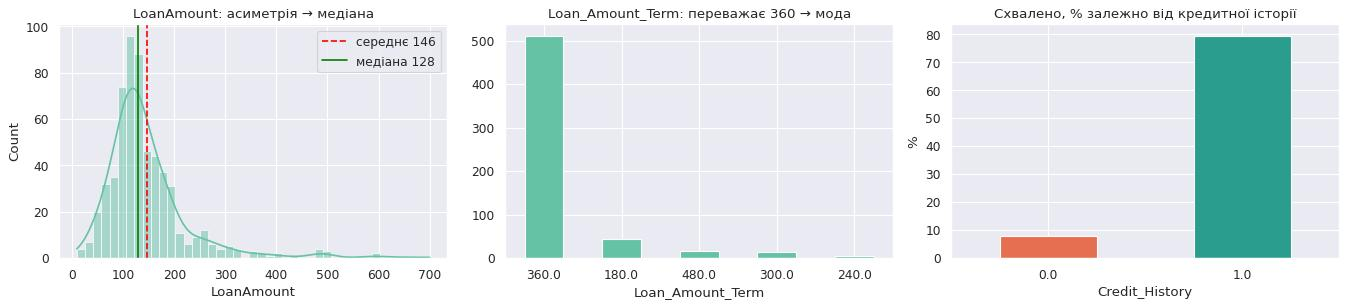

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
sns.histplot(loan["LoanAmount"], ax=axes[0], kde=True)
axes[0].axvline(loan["LoanAmount"].mean(), color="red", ls="--", label=f"середнє {loan['LoanAmount'].mean():.0f}")
axes[0].axvline(loan["LoanAmount"].median(), color="green", label=f"медіана {loan['LoanAmount'].median():.0f}")
axes[0].legend(); axes[0].set_title("LoanAmount: асиметрія → медіана")
loan["Loan_Amount_Term"].value_counts().head(5).plot.bar(ax=axes[1], rot=0); axes[1].set_title("Loan_Amount_Term: переважає 360 → мода")
(loan.groupby("Credit_History")["Loan_Status"].apply(lambda s: (s == "Y").mean() * 100)).plot.bar(ax=axes[2], rot=0, color=["#e76f51", "#2a9d8f"])
axes[2].set_title("Схвалено, % залежно від кредитної історії"); axes[2].set_ylabel("%")
plt.tight_layout(); plt.show()

### 2.2. Розподіл класів у цільовій змінній

Loan_Status
Y    422
N    192
Name: count, dtype: int64 
 Loan_Status
Y    68.7 %
N    31.3 %
Name: count, dtype: str


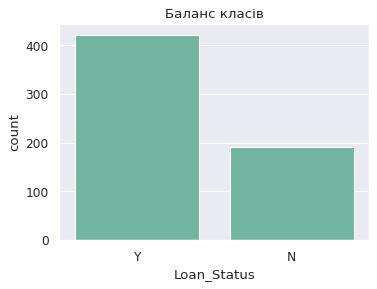

In [5]:
counts = loan["Loan_Status"].value_counts()
print(counts, "\n", (counts / counts.sum() * 100).round(1).astype(str) + " %")
plt.figure(figsize=(5, 3.5)); sns.countplot(data=loan, x="Loan_Status", order=["Y", "N"]); plt.title("Баланс класів"); plt.show()

Класи **помірно незбалансовані**: 68.7 % заявок схвалено, 31.3 % відхилено. Тому розподіл робимо зі стратифікацією, а оцінюємо не лише accuracy, а й precision, recall, F1 та ROC AUC.

## 3. Розподіл даних 80 : 20, заповнення пропусків та кодування

In [6]:
data = loan.drop(columns="Loan_ID")
y = (data.pop("Loan_Status") == "Y").astype(int)
X_train, X_test, y_train, y_test = train_test_split(data, y, test_size=0.2, stratify=y, random_state=SEED)
print("train:", X_train.shape, "| test:", X_test.shape)

# значення для заповнення рахуємо тільки на train
fill = {c: X_train[c].mode()[0] for c in ["Credit_History", "Self_Employed", "Gender", "Married", "Dependents", "Loan_Amount_Term"]}
fill["LoanAmount"] = X_train["LoanAmount"].median()
print("Значення для заповнення:", fill)

def prepare(df):
    df = df.fillna(fill).copy()
    df["Dependents"] = df["Dependents"].replace("3+", "3").astype(int)
    df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]            # нова ознака: сукупний дохід сім'ї
    df["LoanToIncome"] = df["LoanAmount"] * 1000 / df["TotalIncome"]               # навантаження: кредит / дохід
    for c in ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "TotalIncome"]:
        df[c] = np.log1p(df[c])                                                     # логарифм зменшує вплив дуже великих значень
    return pd.get_dummies(df, columns=["Gender", "Married", "Education", "Self_Employed", "Property_Area"], drop_first=True, dtype=int)

Xtr, Xte = prepare(X_train), prepare(X_test)
Xte = Xte.reindex(columns=Xtr.columns, fill_value=0)
print("Пропусків після обробки:", Xtr.isna().sum().sum() + Xte.isna().sum().sum(), "| ознак після one-hot:", Xtr.shape[1])
Xtr.head()

train: (491, 11) | test: (123, 11)
Значення для заповнення: {'Credit_History': np.float64(1.0), 'Self_Employed': 'No', 'Gender': 'Male', 'Married': 'Yes', 'Dependents': '0', 'Loan_Amount_Term': np.float64(360.0), 'LoanAmount': np.float64(127.5)}
Пропусків після обробки: 0 | ознак після one-hot: 14


,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome,LoanToIncome,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
458,2,8.379080,0.000000,4.919981,360.0,1.0,8.379080,31.235645,1,0,0,0,0,0
361,2,8.517393,8.207402,5.468060,360.0,1.0,9.067393,27.229722,1,1,0,0,1,0
365,0,8.735043,0.000000,4.897840,360.0,1.0,8.735043,21.396396,1,0,1,0,0,0
94,0,8.194506,0.000000,3.258097,120.0,1.0,8.194506,6.906077,1,0,1,0,1,0
401,0,7.921536,0.000000,4.189655,300.0,1.0,7.921536,23.593466,1,0,1,0,0,0


In [7]:
scaler = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)    # масштабування потрібне для логістичної регресії, KNN і SVM

## 4. Побудова моделей
### 4.1. Точка відліку: правило «схвалити, якщо є кредитна історія»
Перш ніж навчати моделі, перевіримо найпростіше правило. Модель має бути кращою за нього, інакше вона не потрібна.

In [8]:
rule = (X_test["Credit_History"].fillna(fill["Credit_History"]) == 1).astype(int)
print(f"Правило «є кредитна історія»: accuracy = {accuracy_score(y_test, rule):.3f}, F1 = {f1_score(y_test, rule):.3f}")

Правило «є кредитна історія»: accuracy = 0.837, F1 = 0.895


### 4.2. Вибір k для KNN крос-валідацією

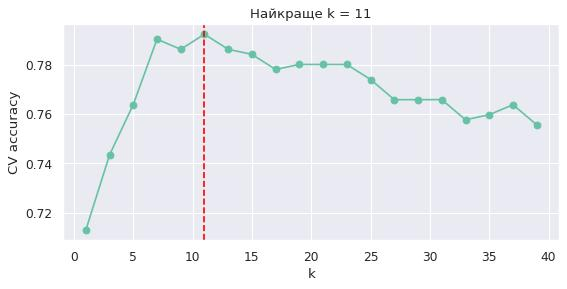

In [9]:
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
ks = list(range(1, 41, 2))
k_scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k), Xtr_s, y_train, cv=cv).mean() for k in ks]
best_k = ks[int(np.argmax(k_scores))]
plt.figure(figsize=(8, 3.5)); plt.plot(ks, k_scores, marker="o"); plt.axvline(best_k, color="red", ls="--")
plt.xlabel("k"); plt.ylabel("CV accuracy"); plt.title(f"Найкраще k = {best_k}"); plt.show()

### 4.3. Навчання: логістична регресія, KNN (основні) + Random Forest, SVM (додаткові)

In [10]:
models = {
    "Логістична регресія": (LogisticRegression(max_iter=1000), True),
    f"KNN (k={best_k})": (KNeighborsClassifier(n_neighbors=best_k), True),
    "Random Forest": (RandomForestClassifier(n_estimators=300, max_depth=5, random_state=SEED), False),
    "SVM (RBF)": (SVC(probability=True, random_state=SEED), True),
}
fitted = {}
for name, (m, scaled) in models.items():
    fitted[name] = (m.fit(Xtr_s if scaled else Xtr, y_train), scaled)
print("Навчено:", list(fitted))

Навчено: ['Логістична регресія', 'KNN (k=11)', 'Random Forest', 'SVM (RBF)']


## 5. Оцінка моделей
### 5.1. Метрики на тестовому наборі

In [11]:
rows, probs, preds = [], {}, {}
for name, (m, scaled) in fitted.items():
    Xe = Xte_s if scaled else Xte
    p, pr = m.predict(Xe), m.predict_proba(Xe)[:, 1]
    preds[name], probs[name] = p, pr
    rows.append({"Модель": name, "Accuracy": accuracy_score(y_test, p), "Precision": precision_score(y_test, p),
                 "Recall": recall_score(y_test, p), "F1-score": f1_score(y_test, p), "ROC AUC": roc_auc_score(y_test, pr),
                 "CV accuracy (train)": cross_val_score(m, Xtr_s if scaled else Xtr, y_train, cv=cv).mean()})
rows.append({"Модель": "Правило «є кредитна історія»", "Accuracy": accuracy_score(y_test, rule), "Precision": precision_score(y_test, rule),
             "Recall": recall_score(y_test, rule), "F1-score": f1_score(y_test, rule), "ROC AUC": roc_auc_score(y_test, rule),
             "CV accuracy (train)": np.nan})
results = pd.DataFrame(rows).set_index("Модель").round(3)
results

,Accuracy,Precision,Recall,F1-score,ROC AUC,CV accuracy (train)
Модель,,,,,,
Логістична регресія,0.846,0.824,0.988,0.898,0.776,0.794
KNN (k=11),0.813,0.792,0.988,0.880,0.785,0.792
Random Forest,0.854,0.832,0.988,0.903,0.836,0.800
SVM (RBF),0.846,0.817,1.000,0.899,0.807,0.798
Правило «є кредитна історія»,0.837,0.810,1.000,0.895,0.737,NaN


### 5.2. Матриці плутанини

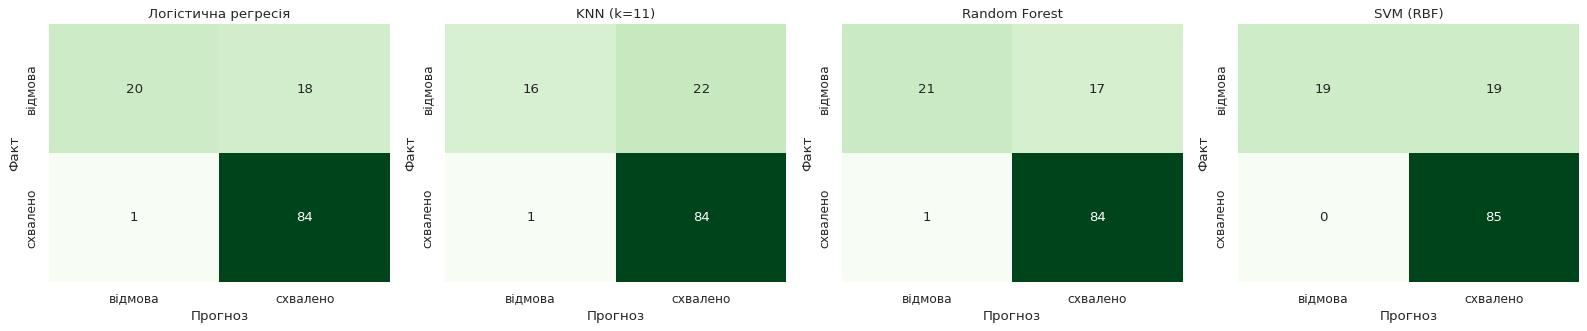

              precision    recall  f1-score   support

 відмова (N)      0.952     0.526     0.678        38
схвалено (Y)      0.824     0.988     0.898        85

    accuracy                          0.846       123
   macro avg      0.888     0.757     0.788       123
weighted avg      0.863     0.846     0.830       123



In [12]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.3))
for ax, (name, p) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, p)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False, ax=ax,
                xticklabels=["відмова", "схвалено"], yticklabels=["відмова", "схвалено"])
    ax.set_title(name); ax.set_xlabel("Прогноз"); ax.set_ylabel("Факт")
plt.tight_layout(); plt.show()
print(classification_report(y_test, preds["Логістична регресія"], target_names=["відмова (N)", "схвалено (Y)"], digits=3))

### 5.3. ROC-криві

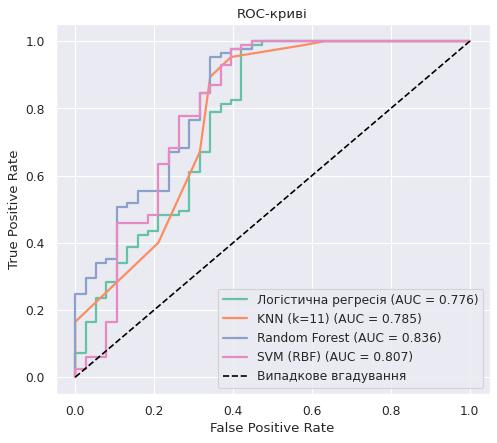

In [13]:
plt.figure(figsize=(7, 6))
for name, pr in probs.items():
    fpr, tpr, _ = roc_curve(y_test, pr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc_score(y_test, pr):.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Випадкове вгадування")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC-криві"); plt.legend(loc="lower right"); plt.show()

## 6. Порівняння моделей

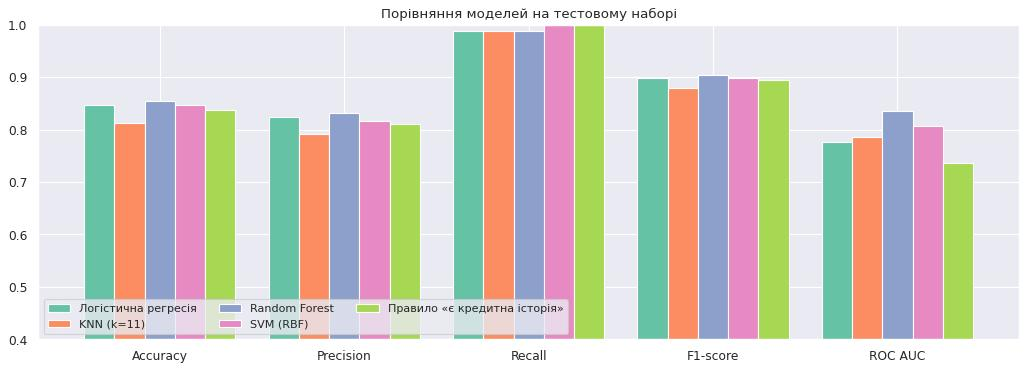

In [14]:
ax = results.drop(columns="CV accuracy (train)").T.plot(kind="bar", figsize=(13, 4.8), rot=0, width=0.82)
ax.set_ylim(0.4, 1.0); ax.set_title("Порівняння моделей на тестовому наборі"); ax.legend(loc="lower left", ncol=3, fontsize=10)
plt.tight_layout(); plt.show()

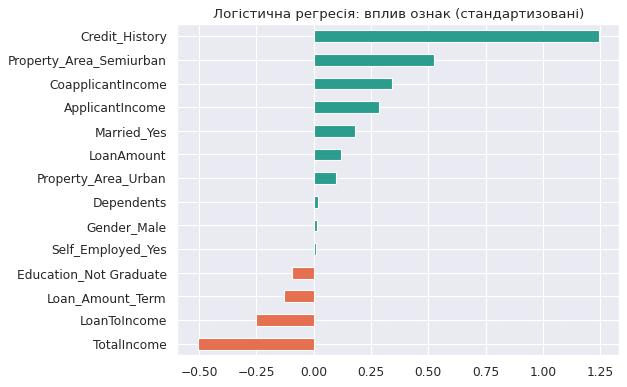

In [15]:
lr = fitted["Логістична регресія"][0]
coef = pd.Series(lr.coef_[0], index=Xtr.columns).sort_values()
coef.plot.barh(figsize=(8, 5), color=np.where(coef > 0, "#2a9d8f", "#e76f51"))
plt.title("Логістична регресія: вплив ознак (стандартизовані)"); plt.tight_layout(); plt.show()

## 7. Звіт і висновки

### Використаний підхід
Набір Kaggle «Loan Prediction» (614 заявок). Пропуски в 7 стовпцях заповнено окремо для кожного: категоріальні й дискретні ознаки **модою**, `LoanAmount` **медіаною** (127.5), бо розподіл сум асиметричний. Значення для заповнення обчислено лише на навчальній частині. Додано дві нові ознаки: сукупний дохід і співвідношення «кредит / дохід». Для доходів і суми кредиту застосовано логарифм, категоріальні змінні закодовано one-hot. Дані розділено 80 : 20 зі стратифікацією (491 / 123). Для KNN параметр k = 11 підібрано крос-валідацією.

### Ключові результати (test, 123 заявки)

| Модель | Accuracy | Precision | Recall | F1 | ROC AUC |
|---|---:|---:|---:|---:|---:|
| Логістична регресія | 0.846 | 0.824 | 0.988 | 0.898 | 0.776 |
| KNN (k = 11) | 0.813 | 0.792 | 0.988 | 0.880 | 0.785 |
| **Random Forest** | **0.854** | **0.832** | 0.988 | **0.903** | **0.836** |
| SVM (RBF) | 0.846 | 0.817 | 1.000 | 0.899 | 0.807 |
| Правило «є кредитна історія» | 0.837 | 0.810 | 1.000 | 0.895 | 0.737 |

### Висновки
1. **Найкраща модель — Random Forest:** accuracy 85.4 %, F1 0.903, ROC AUC 0.836. Серед основних моделей логістична регресія (84.6 %) помітно краща за KNN (81.3 %).
2. **Кредитна історія — вирішальна ознака.** Просте правило «схвалити, якщо є кредитна історія» вже дає 83.7 %. Моделі перевершують його лише на 1–2 п.п. за accuracy, зате суттєво за ROC AUC (0.78–0.84 проти 0.74), тобто краще ранжують заявки за ризиком. Порівняння з простим правилом обов'язкове, щоб не переоцінити складність моделі.
3. **Слабке місце — виявлення відмов.** Схвалені заявки моделі знаходять майже всі (recall 0.99), а відмови лише наполовину: recall класу «відмова» в логістичної регресії 0.53. Для банку це найдорожча помилка, бо ризикова заявка отримує схвалення (FP). Для її зменшення можна підвищити поріг схвалення або застосувати `class_weight="balanced"`.
4. **Оцінка стабільна:** крос-валідація на train дає 79–80 % для всіх моделей, трохи менше, ніж на test. На малому тестовому наборі (123 заявки) різниця в 1–2 п.п. між моделями в межах випадкових коливань.
5. **Практичний висновок:** на 614 заявках складні моделі дають невеликий приріст. Для суттєвого покращення потрібні додаткові дані: історія платежів, наявні борги, стаж роботи.